In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra

import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9531901_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9768219_1.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9718992_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9138554_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9875303_1.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9720535_1.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9639683_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9857555_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/auto_test/2/9082631_2.png
/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/knee-osteoarthritis-dataset-with-severity")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity


In [3]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import torch

In [4]:
class CustomData(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
        
        for cls_name in self.classes:
            folder_path = os.path.join(root_dir, cls_name)
            label = self.class_to_idx[cls_name]
            for img_name in os.listdir(folder_path):
                img_path = os.path.join(folder_path, img_name)
                if os.path.isfile(img_path):
                    self.image_paths.append(img_path)
                    self.labels.append(label)
        

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self,idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path)

        if self.transform:
            image = self.transform(image)
        
        return image, label

In [5]:
root_dir = "./Data/train/"

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),

    transforms.RandomRotation(degrees=10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = CustomData(root_dir='/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/train', transform=train_transforms)
test_dataset = CustomData(root_dir='/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/test', transform=test_transforms)
val_dataset = CustomData(root_dir='/kaggle/input/datasets/shashwatwork/knee-osteoarthritis-dataset-with-severity/val', transform=test_transforms)

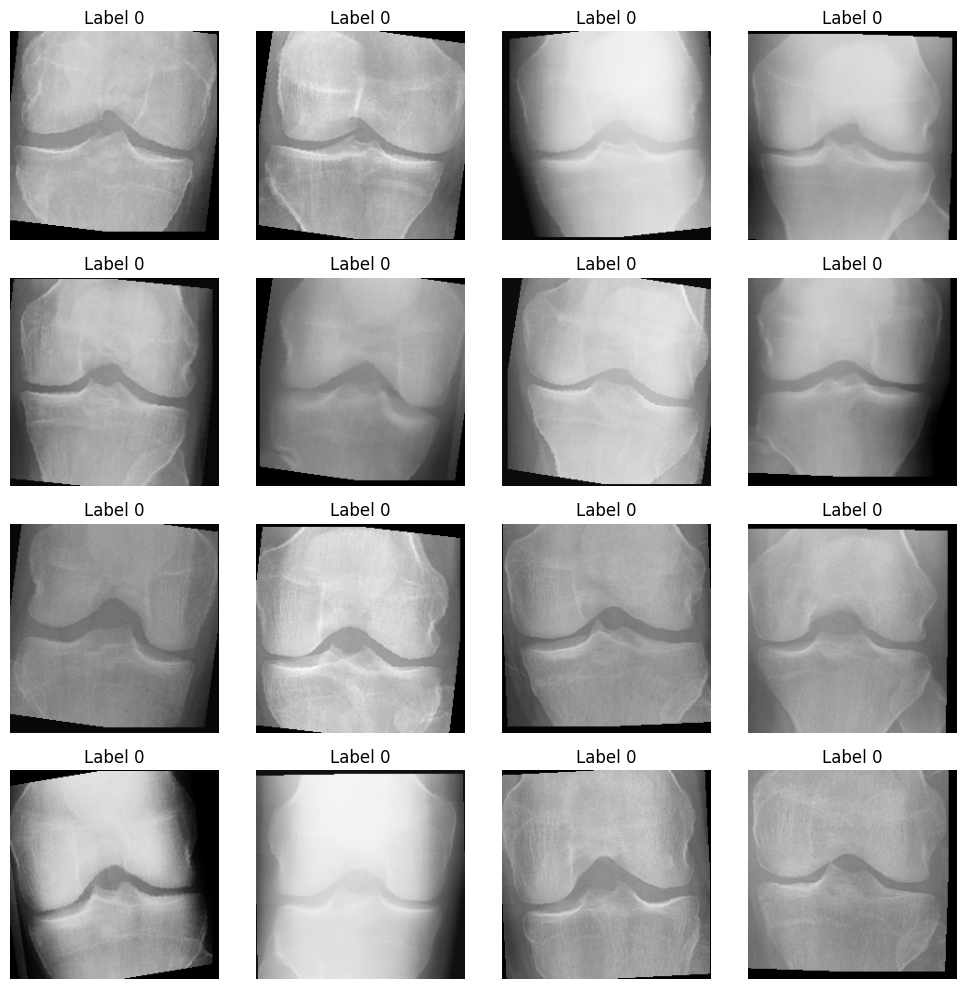

In [7]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    

    img_tensor, label = train_dataset[i]
    

    img_numpy = img_tensor.permute(1, 2, 0).numpy()
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_numpy = std * img_numpy + mean
    
    img_numpy = np.clip(img_numpy, 0, 1)
    
    plt.imshow(img_numpy) 
    plt.title(f"Label {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
print(f"Classes found: {train_dataset.classes}")

Classes found: ['0', '1', '2', '3', '4']


In [9]:
train_loader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=32, shuffle=False)
val_loader = DataLoader(dataset=val_dataset, batch_size=32, shuffle=False)

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


# **First Approch**

In this apprch, we are dealing the labels as distincts labels

In [43]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features 

model.fc = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=5, bias=True)
)
model = model.to(device)

In [44]:
learning_rate = 0.001
epochs = 200

In [45]:
import torch
import numpy as np
from collections import Counter

class_counts = np.bincount(train_dataset.labels)
print("Class Counts:", class_counts)


total_samples = len(train_dataset)
num_classes = len(class_counts)

class_weights = total_samples / (num_classes * class_counts)
print("Calculated Weights:", class_weights)


class_weights_tensor = torch.FloatTensor(class_weights).to(device)


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

Class Counts: [2286 1046 1516  757  173]
Calculated Weights: [0.50551181 1.10478011 0.76226913 1.52655218 6.67976879]


In [46]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
from tqdm.notebook import tqdm 

print("--- PHASE 1: WARM-UP (Training Classifier Only) ---")


model.requires_grad_(False)
model.fc.requires_grad_(True)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-5, weight_decay=1e-3)

phase1_epochs = 5
for epoch in range(phase1_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 1 - Epoch {epoch + 1}/{phase1_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            if val_features.shape[1] == 1:
                val_features = val_features.repeat(1, 3, 1, 1)
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 1 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print("\nPhase 1 Complete. Classifier warmed up.")


print("\n--- PHASE 2: FINE-TUNING (Training Whole Model) ---")



model.requires_grad_(True)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)

phase2_epochs = 30 
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_epochs)

patience = 5  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict()) 

for epoch in range(phase2_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 2 - Epoch {epoch + 1}/{phase2_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        if batch_features.shape[1] == 1:
            batch_features = batch_features.repeat(1, 3, 1, 1)
            
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            if val_features.shape[1] == 1:
                val_features = val_features.repeat(1, 3, 1, 1)
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 2 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')
    

    scheduler.step()

    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        epochs_no_improve = 0
        print("  [*] Validation loss improved. Saving model weights...")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n[!!!] Early stopping triggered. Halting training at Phase 2, epoch {epoch + 1}.")
            break


model.load_state_dict(best_model_wts)
print("\nTraining Complete. Best model weights restored.")

--- PHASE 1: WARM-UP (Training Classifier Only) ---


Phase 1 - Epoch 1/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 01 | Train Loss: 1.6498 | Val Loss: 1.5900


Phase 1 - Epoch 2/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 02 | Train Loss: 1.6470 | Val Loss: 1.5856


...

Phase 2 - Epoch 22 | Train Loss: 0.5093 | Val Loss: 0.9135
  [!] No improvement for 3 epoch(s).


Phase 2 - Epoch 23/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 23 | Train Loss: 0.4995 | Val Loss: 0.9081
  [!] No improvement for 4 epoch(s).


Phase 2 - Epoch 24/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 24 | Train Loss: 0.4891 | Val Loss: 0.9124
  [!] No improvement for 5 epoch(s).

[!!!] Early stopping triggered. Halting training at Phase 2, epoch 24.

Training Complete. Best model weights restored.


In [16]:
print("Starting Testing Phase...")

model.eval() 
correct_predictions = 0
total_samples = 0
total_test_loss = 0


with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for test_features, test_labels in test_bar:
        
   
        if test_features.shape[1] == 1:
            test_features = test_features.repeat(1, 3, 1, 1)
            
        test_features, test_labels = test_features.to(device), test_labels.to(device)
        
        outputs = model(test_features)
        loss = criterion(outputs, test_labels)
        total_test_loss += loss.item()
        
    
        _, predicted_classes = torch.max(outputs, 1)
        

        total_samples += test_labels.size(0)
        correct_predictions += (predicted_classes == test_labels).sum().item()


avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = (correct_predictions / total_samples) * 100

print("-" * 30)
print("FINAL TEST RESULTS:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({correct_predictions}/{total_samples} correct)")
print("-" * 30)

Starting Testing Phase...


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

KeyboardInterrupt: 

Generating detailed performance report...

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     0.7386    0.7074    0.7226       639
           1     0.3068    0.3784    0.3389       296
           2     0.6504    0.5660    0.6053       447
           3     0.7542    0.8117    0.7819       223
           4     0.8400    0.8235    0.8317        51

    accuracy                         0.6280      1656
   macro avg     0.6580    0.6574    0.6561      1656
weighted avg     0.6428    0.6280    0.6337      1656



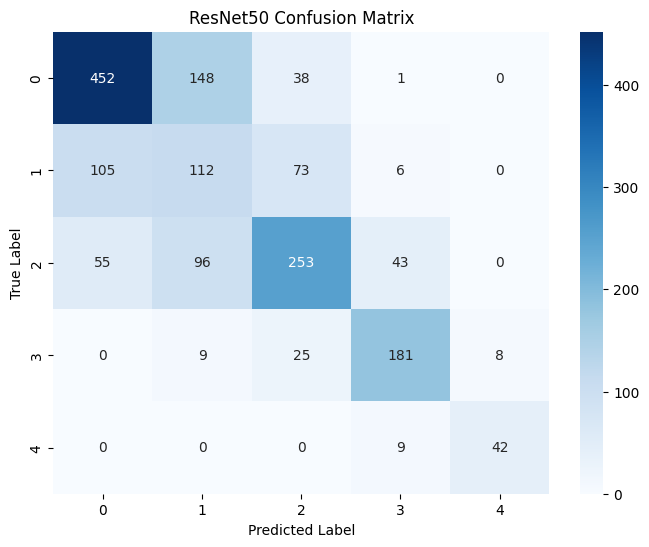

In [48]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

print("Generating detailed performance report...")


all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for test_features, test_labels in test_loader:
        test_features = test_features.to(device)
        outputs = model(test_features)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(test_labels.cpu().numpy())


print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, digits=4))


cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('ResNet50 Confusion Matrix')
plt.show()

# *Second Approch*

Treating the model as regression model and using the following loss function

$$\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} w_{y_i} (\hat{y}_i - y_i)^2$$

In [12]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features 

model.fc = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=1, bias=True) 
)
model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


In [13]:
class WeightedMSELoss(nn.Module):
    def __init__(self, class_weights):
        super().__init__()
        self.class_weights = class_weights

    def forward(self, predictions, targets):

        base_loss = (predictions - targets) ** 2
        batch_weights = self.class_weights[targets.long()]
        weighted_loss = base_loss * batch_weights
        
        return weighted_loss.mean()


weights = [0.50551181, 1.10478011, 0.76226913, 1.52655218, 6.67976879]
class_weights_tensor = torch.FloatTensor(weights).to(device)

criterion = WeightedMSELoss(class_weights_tensor)

In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy
from tqdm.notebook import tqdm 

print("--- PHASE 1: WARM-UP (Training Classifier Only) ---")

model.requires_grad_(False)
model.fc.requires_grad_(True)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-3) 

phase1_epochs = 5
for epoch in range(phase1_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 1 - Epoch {epoch + 1}/{phase1_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        
   
        outputs = model(batch_features).squeeze(1) 
        float_labels = batch_labels.float()
        loss = criterion(outputs, float_labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features).squeeze(1)
            float_labels = val_labels.float()
            loss = criterion(outputs, float_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 1 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')

print("\nPhase 1 Complete. Classifier warmed up.")


print("\n--- PHASE 2: FINE-TUNING (Training Whole Model) ---")

model.requires_grad_(True)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-3)

phase2_epochs = 30 
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_epochs)

patience = 5  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict()) 

for epoch in range(phase2_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 2 - Epoch {epoch + 1}/{phase2_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        

        outputs = model(batch_features).squeeze(1)
        float_labels = batch_labels.float()
        loss = criterion(outputs, float_labels)
        
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            

            outputs = model(val_features).squeeze(1)
            float_labels = val_labels.float()
            loss = criterion(outputs, float_labels)
            total_val_loss += loss.item()
            
 
            rounded_preds = torch.round(outputs)
            predicted_classes = torch.clamp(rounded_preds, 0, 4)
            
            val_total += val_labels.size(0)
            val_correct += (predicted_classes == val_labels).sum().item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total) * 100
    
    print(f'Phase 2 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')
    
    scheduler.step()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        epochs_no_improve = 0
        print("  [*] Validation loss improved. Saving model weights...")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n[!!!] Early stopping triggered. Halting training at Phase 2, epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)
print("\nTraining Complete. Best model weights restored.")

--- PHASE 1: WARM-UP (Training Classifier Only) ---


Phase 1 - Epoch 1/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 01 | Train Loss: 2.1287 | Val Loss: 2.0024


Phase 1 - Epoch 2/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 02 | Train Loss: 1.7176 | Val Loss: 1.5519


...

Phase 2 - Epoch 22 | Train Loss: 0.4368 | Val Loss: 0.4762 | Val Acc: 51.82%
  [!] No improvement for 3 epoch(s).


Phase 2 - Epoch 23/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 23 | Train Loss: 0.4143 | Val Loss: 0.4718 | Val Acc: 51.82%
  [!] No improvement for 4 epoch(s).


Phase 2 - Epoch 24/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 24 | Train Loss: 0.4201 | Val Loss: 0.4975 | Val Acc: 51.21%
  [!] No improvement for 5 epoch(s).

[!!!] Early stopping triggered. Halting training at Phase 2, epoch 24.

Training Complete. Best model weights restored.


Starting Testing Phase (Ordinal Regression)...


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

------------------------------
FINAL TEST RESULTS:
Test Loss: 0.4200
Test Accuracy: 53.32% (883/1656 correct)
------------------------------

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

           0     0.7783    0.5164    0.6209       639
           1     0.2707    0.6284    0.3784       296
           2     0.6088    0.4004    0.4831       447
           3     0.7450    0.6682    0.7045       223
           4     0.7647    0.7647    0.7647        51

    accuracy                         0.5332      1656
   macro avg     0.6335    0.5956    0.5903      1656
weighted avg     0.6369    0.5332    0.5561      1656



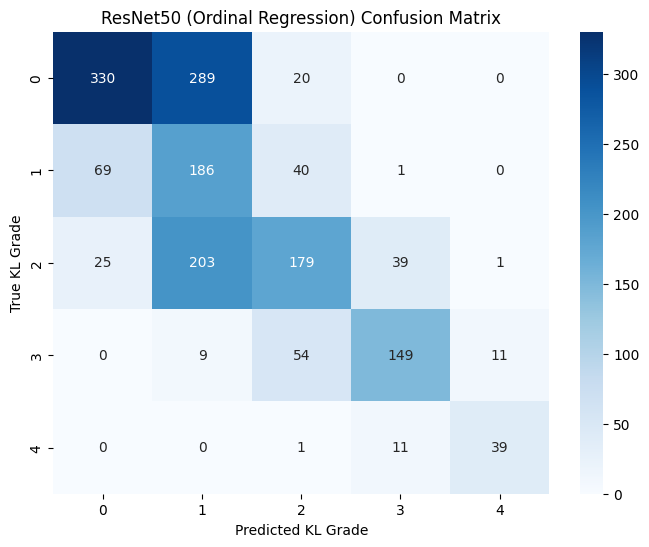

In [18]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import numpy as np
from tqdm.notebook import tqdm 

print("Starting Testing Phase (Ordinal Regression)...")

model.eval() 
correct_predictions = 0
total_samples = 0
total_test_loss = 0


all_preds = []
all_labels = []

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for test_features, test_labels in test_bar:
        
 
        test_features, test_labels = test_features.to(device), test_labels.to(device)
        

        outputs = model(test_features).squeeze(1)
        float_labels = test_labels.float()
        
        loss = criterion(outputs, float_labels)
        total_test_loss += loss.item()
        

        rounded_preds = torch.round(outputs)
        predicted_classes = torch.clamp(rounded_preds, 0, 4)
        

        total_samples += test_labels.size(0)
        correct_predictions += (predicted_classes == test_labels).sum().item()

        all_preds.extend(predicted_classes.cpu().numpy())
        all_labels.extend(test_labels.cpu().numpy())


avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = (correct_predictions / total_samples) * 100

print("-" * 30)
print("FINAL TEST RESULTS:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({correct_predictions}/{total_samples} correct)")
print("-" * 30)


print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted KL Grade')
plt.ylabel('True KL Grade')
plt.title('ResNet50 (Ordinal Regression) Confusion Matrix')
plt.show()

# *Third approach*

Using Binary classification to just identify wether the Arthrites is present or not


Loading ResNet50...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 185MB/s]


--- PHASE 1: WARM-UP ---


Phase 1 - Epoch 1/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 01 | Train Loss: 0.6901 | Val Loss: 0.6339


...

Phase 2 - Epoch 12 | Train Loss: 0.2960 | Val Loss: 0.4189 | Val Acc: 83.54%
  [!] No improvement for 4 epoch(s).


Phase 2 - Epoch 13/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 13 | Train Loss: 0.2778 | Val Loss: 0.4139 | Val Acc: 83.29%
  [!] No improvement for 5 epoch(s).

[!!!] Early stopping triggered. Halting training at epoch 13.

--- FINAL BINARY TESTING PHASE ---


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

------------------------------
FINAL TEST RESULTS:
Test Loss: 0.4057
Test Accuracy: 82.31% (1363/1656 correct)
------------------------------

--- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

Negative/Doubtful (0-1)     0.8210    0.8781    0.8486       935
Positive/Definite (2-4)     0.8262    0.7517    0.7872       721

               accuracy                         0.8231      1656
              macro avg     0.8236    0.8149    0.8179      1656
           weighted avg     0.8233    0.8231    0.8219      1656



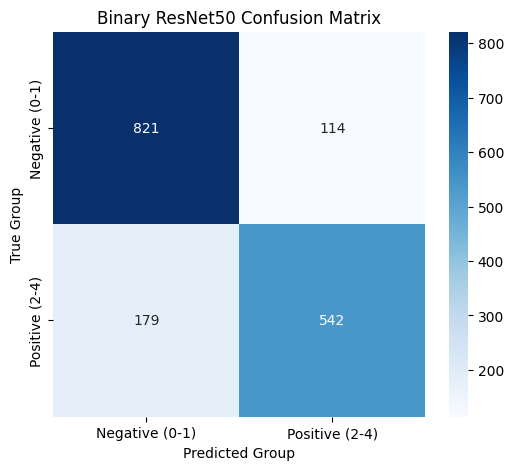

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import resnet50, ResNet50_Weights
import copy
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


print("Loading ResNet50...")
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
num_ftrs = model.fc.in_features 


model.fc = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=2, bias=True) 
)
model = model.to(device)

# Total samples: 5778. Num Classes: 2.
# Weight 0 = 5778 / (2 * 3332) = 0.867
# Weight 1 = 5778 / (2 * 2446) = 1.181
binary_weights = [0.867, 1.181]
class_weights_tensor = torch.FloatTensor(binary_weights).to(device)


criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print("--- PHASE 1: WARM-UP ---")
model.requires_grad_(False)
model.fc.requires_grad_(True)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-3) 

phase1_epochs = 5
for epoch in range(phase1_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 1 - Epoch {epoch + 1}/{phase1_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        
        # If grade >= 2, make it Class 1. Else, make it Class 0.
        batch_labels = (batch_labels >= 2).long()
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_labels = (val_labels >= 2).long() # Map validation labels too!
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 1 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')



print("\n--- PHASE 2: FINE-TUNING ---")
model.requires_grad_(True)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-3)
phase2_epochs = 30 
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_epochs)

patience = 5  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict()) 

for epoch in range(phase2_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 2 - Epoch {epoch + 1}/{phase2_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        
        batch_labels = (batch_labels >= 2).long()
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            # LABEL MAPPING
            val_labels = (val_labels >= 2).long()
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
            # Standard Classification Accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (predicted == val_labels).sum().item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total) * 100
    
    print(f'Phase 2 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')
    scheduler.step()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        epochs_no_improve = 0
        print("  [*] Validation loss improved. Saving model weights...")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n[!!!] Early stopping triggered. Halting training at epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)


print("\n--- FINAL BINARY TESTING PHASE ---")
model.eval() 
correct_predictions = 0
total_samples = 0
total_test_loss = 0

all_preds = []
all_labels = []

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for test_features, test_labels in test_bar:

        test_labels = (test_labels >= 2).long()
        test_features, test_labels = test_features.to(device), test_labels.to(device)
        
        outputs = model(test_features)
        loss = criterion(outputs, test_labels)
        total_test_loss += loss.item()
        
        _, predicted_classes = torch.max(outputs, 1)
        
        total_samples += test_labels.size(0)
        correct_predictions += (predicted_classes == test_labels).sum().item()
        
        all_preds.extend(predicted_classes.cpu().numpy())
        all_labels.extend(test_labels.cpu().numpy())

avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = (correct_predictions / total_samples) * 100

print("-" * 30)
print("FINAL TEST RESULTS:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({correct_predictions}/{total_samples} correct)")
print("-" * 30)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=["Negative/Doubtful (0-1)", "Positive/Definite (2-4)"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative (0-1)", "Positive (2-4)"], yticklabels=["Negative (0-1)", "Positive (2-4)"])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.title('Binary ResNet50 Confusion Matrix')
plt.show()

## Using Dense Net

with Focal Loss;
$$FL(p_t) = -\alpha_t (1 - p_t)^\gamma \log(p_t)$$

Loading DenseNet121...
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 139MB/s] 


--- PHASE 1: WARM-UP ---


Phase 1 - Epoch 1/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 01 | Train Loss: 0.2210 | Val Loss: 0.1600


...

Phase 2 - Epoch 15 | Train Loss: 0.0890 | Val Loss: 0.1082 | Val Acc: 81.48%
  [!] No improvement for 4 epoch(s).


Phase 2 - Epoch 16/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 16 | Train Loss: 0.0860 | Val Loss: 0.1113 | Val Acc: 80.15%
  [!] No improvement for 5 epoch(s).

[!!!] Early stopping triggered. Halting training at epoch 16.

--- FINAL BINARY TESTING PHASE ---


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

------------------------------
FINAL TEST RESULTS:
Test Loss: 0.1055
Test Accuracy: 80.62% (1335/1656 correct)
------------------------------

--- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

Negative/Doubtful (0-1)     0.8449    0.8043    0.8241       935
Positive/Definite (2-4)     0.7611    0.8086    0.7841       721

               accuracy                         0.8062      1656
              macro avg     0.8030    0.8064    0.8041      1656
           weighted avg     0.8084    0.8062    0.8067      1656



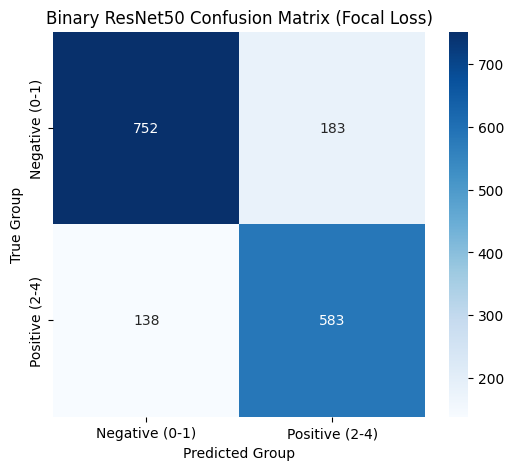

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import densenet121, DenseNet121_Weights
import copy
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


print("Loading DenseNet121...")
model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier.in_features 

# Only 2 output features now! (Negative vs. Positive)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=2, bias=True) 
)
model = model.to(device)


class FocalLoss(nn.Module):
    """
    Focal Loss pushes the model to focus on hard, borderline examples.
    gamma: focusing parameter (usually 2.0). Higher = more focus on hard examples.
    alpha: class weights to handle imbalance.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        # Calculate standard Cross Entropy Loss without reduction
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        
        # Get the probability of the correct class (pt)
        pt = torch.exp(-ce_loss)
        
        # Apply the focal loss formula: alpha * (1 - pt)^gamma * CE_loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        return focal_loss.mean()

# Total samples: 5778. Num Classes: 2.
# Weight 0 = 5778 / (2 * 3332) = 0.867
# Weight 1 = 5778 / (2 * 2446) = 1.181
binary_weights = [0.867, 1.181]
class_weights_tensor = torch.FloatTensor(binary_weights).to(device)

# Initialize Focal Loss instead of CrossEntropyLoss
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0)


print("--- PHASE 1: WARM-UP ---")
model.requires_grad_(False)
model.classifier.requires_grad_(True)
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-3, weight_decay=1e-3) 

phase1_epochs = 5
for epoch in range(phase1_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 1 - Epoch {epoch + 1}/{phase1_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        
        # If grade >= 2, make it Class 1. Else, make it Class 0.
        batch_labels = (batch_labels >= 2).long()
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_labels = (val_labels >= 2).long() # Map validation labels too!
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 1 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')



print("\n--- PHASE 2: FINE-TUNING ---")
model.requires_grad_(True)
optimizer = optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-3)
phase2_epochs = 30 
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_epochs)

patience = 5  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict()) 

for epoch in range(phase2_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 2 - Epoch {epoch + 1}/{phase2_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        # LABEL MAPPING
        batch_labels = (batch_labels >= 2).long()
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            # LABEL MAPPING
            val_labels = (val_labels >= 2).long()
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
            # Standard Classification Accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (predicted == val_labels).sum().item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total) * 100
    
    print(f'Phase 2 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')
    scheduler.step()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        epochs_no_improve = 0
        print("  [*] Validation loss improved. Saving model weights...")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n[!!!] Early stopping triggered. Halting training at epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)


print("\n--- FINAL BINARY TESTING PHASE ---")
model.eval() 
correct_predictions = 0
total_samples = 0
total_test_loss = 0

all_preds = []
all_labels = []

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for test_features, test_labels in test_bar:
        # LABEL MAPPING
        test_labels = (test_labels >= 2).long()
        test_features, test_labels = test_features.to(device), test_labels.to(device)
        
        outputs = model(test_features)
        loss = criterion(outputs, test_labels)
        total_test_loss += loss.item()
        
        _, predicted_classes = torch.max(outputs, 1)
        
        total_samples += test_labels.size(0)
        correct_predictions += (predicted_classes == test_labels).sum().item()
        
        all_preds.extend(predicted_classes.cpu().numpy())
        all_labels.extend(test_labels.cpu().numpy())

avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = (correct_predictions / total_samples) * 100

print("-" * 30)
print("FINAL TEST RESULTS:")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({correct_predictions}/{total_samples} correct)")
print("-" * 30)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=["Negative/Doubtful (0-1)", "Positive/Definite (2-4)"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative (0-1)", "Positive (2-4)"], yticklabels=["Negative (0-1)", "Positive (2-4)"])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.title('Binary ResNet50 Confusion Matrix (Focal Loss)')
plt.show()

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision.models import densenet121, DenseNet121_Weights
import copy
import numpy as np
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


print("Loading DenseNet121...")
model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
num_ftrs = model.classifier.in_features 

# Only 2 output features now! (Negative vs. Positive)
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=2, bias=True) 
)
model = model.to(device)


class FocalLoss(nn.Module):
    """
    Focal Loss pushes the model to focus on hard, borderline examples.
    gamma: focusing parameter (usually 2.0). Higher = more focus on hard examples.
    alpha: class weights to handle imbalance.
    label_smoothing: Prevents overconfidence by softening target labels.
    """
    def __init__(self, alpha=None, gamma=2.0, label_smoothing=0.1):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, inputs, targets):
        # Calculate standard Cross Entropy Loss WITH Label Smoothing
        ce_loss = F.cross_entropy(
            inputs, targets, 
            reduction='none', 
            weight=self.alpha, 
            label_smoothing=self.label_smoothing
        )
        
        # Get the probability of the correct class (pt)
        pt = torch.exp(-ce_loss)
        
        # Apply the focal loss formula: alpha * (1 - pt)^gamma * CE_loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        
        return focal_loss.mean()

# Total samples: 5778. Num Classes: 2.
# Weight 0 = 5778 / (2 * 3332) = 0.867
# Weight 1 = 5778 / (2 * 2446) = 1.181
binary_weights = [0.867, 1.181]
class_weights_tensor = torch.FloatTensor(binary_weights).to(device)

# Initialize Focal Loss with label smoothing
criterion = FocalLoss(alpha=class_weights_tensor, gamma=2.0, label_smoothing=0.1)


print("--- PHASE 1: WARM-UP ---")
model.requires_grad_(False)
model.classifier.requires_grad_(True)

# Switched to AdamW for better Weight Decay generalization
optimizer = optim.AdamW(model.classifier.parameters(), lr=1e-3, weight_decay=1e-2) 

phase1_epochs = 5
for epoch in range(phase1_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 1 - Epoch {epoch + 1}/{phase1_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        
        # LABEL MAPPING: If grade >= 2, make it Class 1. Else, make it Class 0.
        batch_labels = (batch_labels >= 2).long()
        
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            val_labels = (val_labels >= 2).long() # Map validation labels too!
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    print(f'Phase 1 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}')


print("\n--- PHASE 2: FINE-TUNING ---")
model.requires_grad_(True)

# OPTIMIZATION: Switched to AdamW with 1e-2 weight decay
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-2)
phase2_epochs = 30 
scheduler = CosineAnnealingLR(optimizer, T_max=phase2_epochs)

patience = 5  
best_val_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict()) 

for epoch in range(phase2_epochs):
    model.train()
    total_train_loss = 0
    
    train_bar = tqdm(train_loader, desc=f'Phase 2 - Epoch {epoch + 1}/{phase2_epochs} [Train]', leave=False)
    for batch_features, batch_labels in train_bar:
        # LABEL MAPPING
        batch_labels = (batch_labels >= 2).long()
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_features)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        train_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = total_train_loss / len(train_loader)

    model.eval() 
    total_val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        for val_features, val_labels in val_loader:
            # LABEL MAPPING
            val_labels = (val_labels >= 2).long()
            val_features, val_labels = val_features.to(device), val_labels.to(device)
            
            outputs = model(val_features)
            loss = criterion(outputs, val_labels)
            total_val_loss += loss.item()
            
            # Standard Classification Accuracy
            _, predicted = torch.max(outputs, 1)
            val_total += val_labels.size(0)
            val_correct += (predicted == val_labels).sum().item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_accuracy = (val_correct / val_total) * 100
    
    print(f'Phase 2 - Epoch {epoch + 1:02d} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}%')
    scheduler.step()
    
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict()) 
        epochs_no_improve = 0
        print("  [*] Validation loss improved. Saving model weights...")
    else:
        epochs_no_improve += 1
        print(f"  [!] No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\n[!!!] Early stopping triggered. Halting training at epoch {epoch + 1}.")
            break

model.load_state_dict(best_model_wts)


Loading DenseNet121...
--- PHASE 1: WARM-UP ---


Phase 1 - Epoch 1/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 01 | Train Loss: 0.2149 | Val Loss: 0.1724


Phase 1 - Epoch 2/5 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 1 - Epoch 02 | Train Loss: 0.1801 | Val Loss: 0.1588


...

Phase 2 - Epoch 15/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 15 | Train Loss: 0.0920 | Val Loss: 0.1107 | Val Acc: 80.51%
  [!] No improvement for 4 epoch(s).


Phase 2 - Epoch 16/30 [Train]:   0%|          | 0/181 [00:00<?, ?it/s]

Phase 2 - Epoch 16 | Train Loss: 0.0920 | Val Loss: 0.1103 | Val Acc: 81.96%
  [!] No improvement for 5 epoch(s).

[!!!] Early stopping triggered. Halting training at epoch 16.


<All keys matched successfully>


--- FINAL BINARY TESTING PHASE ---


Testing:   0%|          | 0/52 [00:00<?, ?it/s]

------------------------------
FINAL TEST RESULTS (Threshold = 0.49):
Test Loss: 0.1092
Test Accuracy: 80.74% (1337/1656 correct)
------------------------------

--- CLASSIFICATION REPORT ---
                         precision    recall  f1-score   support

Negative/Doubtful (0-1)     0.8492    0.8011    0.8244       935
Positive/Definite (2-4)     0.7597    0.8155    0.7866       721

               accuracy                         0.8074      1656
              macro avg     0.8044    0.8083    0.8055      1656
           weighted avg     0.8102    0.8074    0.8080      1656



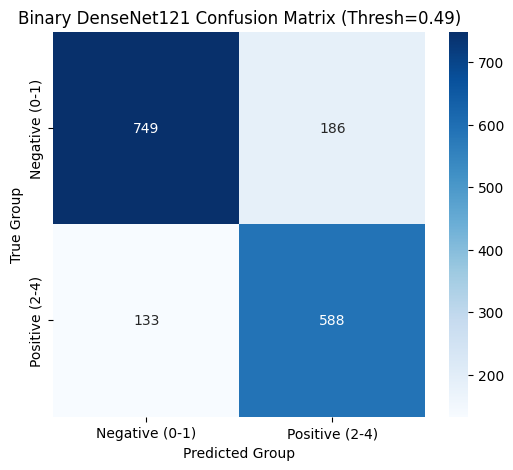

In [23]:
print("\n--- FINAL BINARY TESTING PHASE ---")
model.eval() 
correct_predictions = 0
total_samples = 0
total_test_loss = 0

all_preds = []
all_labels = []

# Manually tweak this to boost accuracy! Try 0.45, 0.55, 0.60
THRESHOLD = 0.49 

with torch.no_grad():
    test_bar = tqdm(test_loader, desc='Testing')
    for test_features, test_labels in test_bar:
        # LABEL MAPPING
        test_labels = (test_labels >= 2).long()
        test_features, test_labels = test_features.to(device), test_labels.to(device)
        
        outputs = model(test_features)
        loss = criterion(outputs, test_labels)
        total_test_loss += loss.item()
        
        # Convert raw outputs to probabilities using Softmax
        probabilities = F.softmax(outputs, dim=1)
        
        # Get the probability of Class 1 (Positive)
        prob_positive = probabilities[:, 1]
        
        # Apply the custom threshold!
        predicted_classes = (prob_positive >= THRESHOLD).long()
        
        total_samples += test_labels.size(0)
        correct_predictions += (predicted_classes == test_labels).sum().item()
        
        all_preds.extend(predicted_classes.cpu().numpy())
        all_labels.extend(test_labels.cpu().numpy())

avg_test_loss = total_test_loss / len(test_loader)
test_accuracy = (correct_predictions / total_samples) * 100

print("-" * 30)
print(f"FINAL TEST RESULTS (Threshold = {THRESHOLD}):")
print(f"Test Loss: {avg_test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}% ({correct_predictions}/{total_samples} correct)")
print("-" * 30)

print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(all_labels, all_preds, target_names=["Negative/Doubtful (0-1)", "Positive/Definite (2-4)"], digits=4))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative (0-1)", "Positive (2-4)"], yticklabels=["Negative (0-1)", "Positive (2-4)"])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.title(f'Binary DenseNet121 Confusion Matrix (Thresh={THRESHOLD})')
plt.show()

In [24]:
model

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [25]:
print("\n--- SAVING MODEL ---")
save_path = "/kaggle/working/best_densenet121_binary.pth"
torch.save(model.state_dict(), save_path)
print(f"Model weights successfully saved to: {save_path}")


--- SAVING MODEL ---
Model weights successfully saved to: /kaggle/working/best_densenet121_binary.pth


In [26]:
from torchvision.models import densenet121
import torch.nn as nn
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
loaded_model = densenet121()
num_ftrs = loaded_model.classifier.in_features 

loaded_model.classifier = nn.Sequential(
    nn.Dropout(p=0.5, inplace=True),
    nn.Linear(in_features=num_ftrs, out_features=2, bias=True) 
)


loaded_model.load_state_dict(torch.load("/kaggle/working/best_densenet121_binary.pth", map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval() # Set to evaluation mode!

print("Model loaded and ready for predictions!")


Model loaded and ready for predictions!


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu